# Assignment 4.1

Name:  
Date:

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem # 4.1.

For a point estimate of the mean of a population that is assumed to have a normal distribution,
a data scientist decides to use the average of the sample lower and upper quartiles for the $n = 100$
observations, since unlike the sample mean $\bar{Y}$, the quartiles are not affected by outliers. Evaluate
the precision of this estimator compared to $\bar{Y}$ by randomly generating 100,000 samples of size
100 each from a $N(0, 1)$ distribution and comparing the standard deviation of the 100,000
estimates with the theoretical standard error of $\bar{Y}$.

`Your answer goes here`

In [1]:
import numpy as np

# Sample Size
n = 100
SAMPLES = int(1e5)

# Random seed for reproducibility
rng = np.random.default_rng(73)

# Normal dist params
sig = 1
mew = 0

# Critical values
Z_68 = 1
Z_95 = 1.96
Z_99 = 2.576

# Generating 100_000 samples of size 100 w/ avg of lower/upper quartiles
y = []
for samp in range(SAMPLES):
    # Generating random variates
    x = rng.normal(size=n)
    # Average of 3rd and 1st quartile
    y_bar_i = (np.quantile(x, 0.75) + np.quantile(x, 0.25)) / 2
    y.append(y_bar_i)

# Estimate standard deviation (not sample, population estimate)
est_std = np.std(y, ddof=1)
y_bar = np.mean(y)

# Theoretical standard error
se = sig / np.sqrt(n)

print(f"Estimated standard deviation: {est_std:.3f}")
print(f"Theoretical standard error: {se:.3f}")
print(f"Mean of estimator (sampling mean): {y_bar:.3f}\n")

# Confidence Intervals to evaluate precision
# Confidence Levels: 68, 95, 99 % w/ critical values: 1, 1.96, 2.576
ci_68_q = (mew - Z_68 * est_std, mew + Z_68 * est_std)
ci_95_q = (mew - Z_95 * est_std, mew + Z_95 * est_std)
ci_99_q = (mew - Z_99 * est_std, mew + Z_99 * est_std)

# Confidence Intervals for the sample mean
ci_68 = (mew - Z_68 * se, mew + Z_68 * se)
ci_95 = (mew - Z_95 * se, mew + Z_95 * se)
ci_99 = (mew - Z_99 * se, mew + Z_99 * se)

print("Typical Error bands for estimator (quartile):")
print(f"68% CI: ({ci_68_q[0]:.3f}, {ci_68_q[1]:.3f})")
print(f"95% CI: ({ci_95_q[0]:.3f}, {ci_95_q[1]:.3f})")
print("Confidence INtervals for sample mean:")
print(f"68% CI: ({ci_68[0]:.3f}, {ci_68[1]:.3f})")
print(f"95% CI: ({ci_95[0]:.3f}, {ci_95[1]:.3f})")
print(f"99% CI: ({ci_99[0]:.3f}, {ci_99[1]:.3f})")

# Interpretation
print("\nINTERPRETATION:")
print(60*"+")
print(f"""
Quartile-based estimator is approximately unbiased, since the sampling mean ({y_bar:.3f}) which is almost equal to the true population mean ({mew}).
sampling variability is higher than the sample mean, where the estimated SD (quartile) is {est_std:.3f} and the theoretical standard deviation is {se:.3f}.
This shows an increase in variabiliity of about {((est_std)/se - 1)*100:.1f}% relative to sample mean.
The confidence intervals based on quartiles are wider for each, meaning lowercprecision.

When the data contains no outliers (as with our N(0,1) simulation), the midhinge's robustness provides no benefit, yet we still pay the cost of increased variance."
      """)
print(60*"+")


Estimated standard deviation: 0.111
Theoretical standard error: 0.100
Mean of estimator (sampling mean): 0.000

Typical Error bands for estimator (quartile):
68% CI: (-0.111, 0.111)
95% CI: (-0.218, 0.218)
Confidence INtervals for sample mean:
68% CI: (-0.100, 0.100)
95% CI: (-0.196, 0.196)
99% CI: (-0.258, 0.258)

INTERPRETATION:
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Quartile-based estimator is approximately unbiased, since the sampling mean (0.000) which is almost equal to the true population mean (0).
sampling variability is higher than the sample mean, where the estimated SD (quartile) is 0.111 and the theoretical standard deviation is 0.100.
This shows an increase in variabiliity of about 11.1% relative to sample mean.
The confidence intervals based on quartiles are wider for each, meaning lowercprecision.

When the data contains no outliers (as with our N(0,1) simulation), the midhinge's robustness provides no benefit, yet we still pay the cost of increase

## Problem # 4.2.

For a sequence of observations of a binary random variable, you observe the geometric random
variable (Section 2.2.2) outcome of the first success on observation number $y = 3$. Find and plot
the likelihood function.

`Your answer goes here`

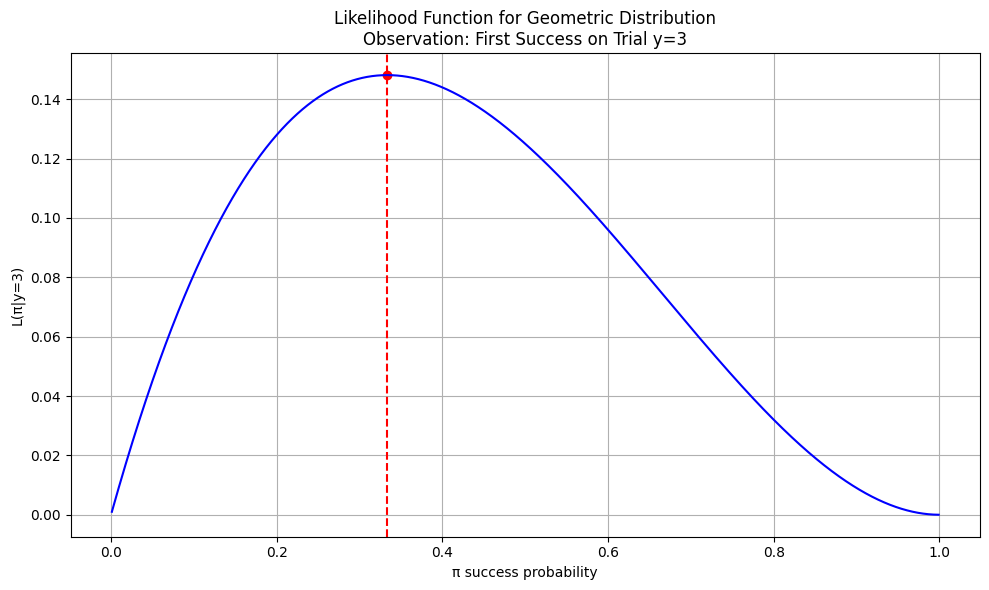

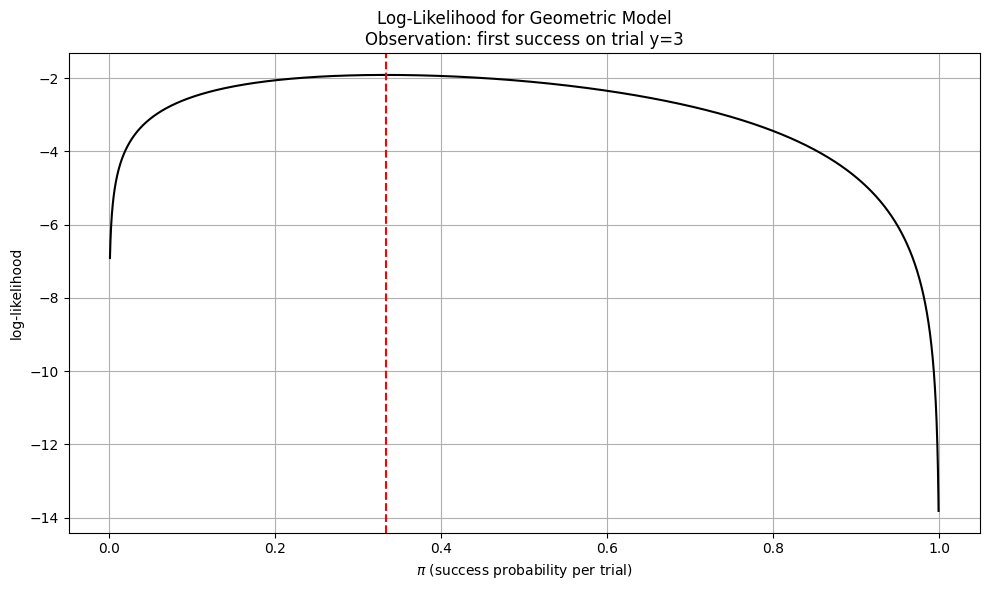


The likelihood function is L(π) = (1 - π)^(y-1), where π is the trial of each success probbability, and L(π) measures how compatible each π s with the observed data y = 3.  

IT's maximized at π̂ = 1 / y = 0.333, which is the maximium likelihood estimate of the success probability, which shows that two failures followed by a success.
      


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# First success @ y = 3
y = 3

# Array of possible pi values, arbitrarily chosen number of samples
pi_pts = np.linspace(0.001, 0.999, int(1e4))

# Likelihood for geometric dist
L = ((1 - pi_pts)**(y-1)) * pi_pts

# MLE
pi_hat = 1 / y

# Likelihood @ MLE for marking in plot
L_hat = ((1 - pi_hat)**(y-1)) * pi_hat

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(pi_pts, L, "b-", label="Likelihood: L(\u03C0) = P(Y=3 | \u03C0)"
)
plt.axvline(pi_hat, color="red", linestyle="--", label=f"MLE: pi_hat = 1 / {y} = {pi_hat:.3f}")
plt.scatter([pi_hat], [L_hat], color="red")
plt.xlabel("\u03C0 success probability")
plt.ylabel("L(\u03C0|y=3)")
plt.title("Likelihood Function for Geometric Distribution\nObservation: First Success on Trial y=3")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting the log-likelihood
logL = np.log(L)

plt.figure(figsize=(10, 6))
plt.plot(pi_pts, logL, "k-", label=r"$\ell(\pi)=\log L(\pi)$")
plt.axvline(pi_hat, color="red", linestyle="--", label=f"MLE: {pi_hat:.3f}")
plt.xlabel(r"$\pi$ (success probability per trial)")
plt.ylabel(r"log-likelihood")
plt.title(f"Log-Likelihood for Geometric Model\nObservation: first success on trial y={y}")
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretation
print(f"""
The likelihood function is L(\u03C0) = (1 - \u03C0)^(y-1), where \u03C0 is the trial of each success probbability, and L(\u03C0) measures how compatible each \u03C0 s with the observed data y = {y}.  

IT's maximized at \u03C0\u0302 = 1 / y = {pi_hat:.3f}, which is the maximium likelihood estimate of the success probability, which shows that two failures followed by a success.
      """)


## Problem # 4.11.

The observations on number of hours of daily TV watching for the 10 subjects in the 2018 GSS
who identified themselves as Islamic were 0, 0, 1, 1, 1, 2, 2, 3, 3, 4.

(a)  Construct and interpret a 95% confidence interval for the population mean.
(b)  Suppose the observation of 4 was incorrectly recorded as 24. What would you obtain for
the 95% confidence interval? What does this suggest about potential effects of outliers on
confidence intervals for means?

`(a) Your answer goes here`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from textwrap import dedent

def ci_construction(y, cl=0.95):
    """
    Constructs a Confidence interval for the given sample with quantitative (discrete) values in order to infer the unknown population mean.
    ------------------------------------------------
    INPUT:
        y: (list, np.array, pd.DataFrame, pd.Series) Sample of values (not a large sample).
        cl: (float) Confindence Level (default 0.95)

    OUTPUT:
        tuple of values: (sample mean, sample standard deviation, standard error, degrees of freedom, t-critical value, margine of error, confidence interval)
    """
    if isinstance(y, pd.DataFrame):
        y = y.loc[:, 0]

    if isinstance(y, pd.Series):
        y = y.to_numpy()

    # Sample size
    n = len(y)

    # Confidence Level check
    if cl == 0.95:
        # t quantile having probability a in the right-tail
        alpha = 0.025

    else:
        alpha = (1 - cl) / 2

    # Sample Statistics
    mew_hat = sum(y) / n # sample meann
    std = np.std(y, ddof=1) # Sample standard deviatition
    se = std / np.sqrt(n) # Standard error

    # t-critical value
    df = n - 1 # Degrees of freedom
    t_crit = t.ppf(1 - alpha, df=df)

    # Margin of error
    me = t_crit * se

    # Confidence Interval for confidence level 95%
    ci = (mew_hat - me, mew_hat + me)

    return (mew_hat, std, se, df, t_crit, me, ci)


# Part a) - unpack results once
# a)
y = [0, 0, 1, 1, 1, 2, 2, 3, 3, 4]
n = len(y) # Sample size
mew_hat, std, se, df, t_crit, me, ci = ci_construction(y)

print(f"Fore the sample: {y}")
print(f"Sample Mean: {mew_hat:.3f}")
print(f"Sampe Standard Deviation: {std:.3f}")
print(f"Standard Error: {se:.3f}")
print(f"Degrees of Freedom: df = {n} - 1 = {df}")
print(f"t-critical value for a 95% CI: {t_crit:.3f}")
print(f"Margin of Error: {me:.3f}")
print(f"Confidence interval: ({ci[0]:.3f}, {ci[1]:.3f})")

# Interpretation
print(dedent(f"""a)
    Assumptions: Normal distribution of the population.
    We can be 95% confident that the true population for the daily hours spent watching tv is lies between {ci[0]:.3f} and {ci[1]:.3f} hours per day.
    Confidence interval made by using a t-distribution since the population std dev is uknown, with a small sample size of {n}.  the interval shows the sample mean {mew_hat:.3f} and sampling variabislity of the mean as the standard error {se:.3f}.

    Interpreted probabilistically, if we were to repeatedly take many rand samples of size 10 from this population mean and construct a 95% confidence interval in the same way each time, approximately 95% of those intervals would contain the true population mean.
    """))



Fore the sample: [0, 0, 1, 1, 1, 2, 2, 3, 3, 4]
Sample Mean: 1.700
Sampe Standard Deviation: 1.337
Standard Error: 0.423
Degrees of Freedom: df = 10 - 1 = 9
t-critical value for a 95% CI: 2.262
Margin of Error: 0.957
Confidence interval: (0.743, 2.657)
a)
    Assumptions: Normal distribution of the population.
    We can be 95% confident that the true population for the daily hours spent watching tv is lies between 0.743 and 2.657 hours per day.
    Confidence interval made by using a t-distribution since the population std dev is uknown, with a small sample size of 10.  the interval shows the sample mean 1.700 and sampling variabislity of the mean as the standard error 0.423.

    Interpreted probabilistically, if we were to repeatedly take many rand samples of size 10 from this population mean and construct a 95% confidence interval in the same way each time, approximately 95% of those intervals would contain the true population mean.



`(b) Your answer goes here`

In [3]:
# b)
y_24 = [0, 0, 1, 1, 1, 2, 2, 3, 3, 24]

# Part b) - unpack results once
mew_hat_24, std_24, se_24, df_24, t_crit_24, me_24, ci_24 = ci_construction(y_24)

print(f"Fore the sample: {y_24}")
print(f"Sample Mean: {mew_hat_24:.3f}")
print(f"Sampe Standard Deviation: {std_24:.3f}")
print(f"Standard Error: {se_24:.3f}")
print(f"Degrees of Freedom: df = {n} - 1 = {df_24}")
print(f"t-critical value for a 95% CI: {t_crit_24:.3f}")
print(f"Margin of Error: {me_24:.3f}")
print(f"Confidence interval: ({ci_24[0]:.3f}, {ci_24[1]:.3f})")

# Interprtation
print(dedent(f"""
    b)
    Using data where the value 24 was incorrectly recorded, we get a 95% confidence
    interval for the population mean for the daily number of hours of tv
    watching as ({ci_24[0]:.3f}, {ci_24[1]:.3f}),
    which is a lot wider than in part a) since the outlier throws off the
    sample mean {mew_hat_24:.3f} and inflates the sample standard
    error {std_24:.3f}, which increases the standard error
    {se_24:.3f} along with the margin of error
    {me_24:.3f}
    """))


Fore the sample: [0, 0, 1, 1, 1, 2, 2, 3, 3, 24]
Sample Mean: 3.700
Sampe Standard Deviation: 7.212
Standard Error: 2.281
Degrees of Freedom: df = 10 - 1 = 9
t-critical value for a 95% CI: 2.262
Margin of Error: 5.159
Confidence interval: (-1.459, 8.859)

b)
Using data where the value 24 was incorrectly recorded, we get a 95% confidence
interval for the population mean for the daily number of hours of tv
watching as (-1.459, 8.859),
which is a lot wider than in part a) since the outlier throws off the
sample mean 3.700 and inflates the sample standard
error 7.212, which increases the standard error
2.281 along with the margin of error
5.159



## Problem # 4.14.

Using the Students data file, for the corresponding population, construct a 95% confidence interval **(a)** for the mean weekly number of hours spent watching TV; **(b)** to compare females and
males on the mean weekly number of hours spent watching TV. In each case, state assumptions,
including the practical importance of each, and interpret results.

`Your answer goes here`

In [10]:
import numpy as np
from scipy.stats import t
import pandas as pd
from textwrap import dedent
from assign4_11 import ci_construction

df = pd.read_csv("./students.dat", sep="\s+")

# a) variables in quetion
tv_hrs = df["tv"]

# Calculate confidence interval w/ all relevant statistical values
results = ci_construction(tv_hrs)
mew_hat, s, se, dfree, tcrit, me, ci = results

print("95% Confidence Interval for Mean Weekly TV Hours")
print("=" * 20)
print(f"Sample mean (ȳ): {mew_hat:.2f} hours/week")
print(f"Sample standard deviation (s): {s:.2f}")
print(f"Standard error (SE = s/√n): {se:.2f}")
print(f"Degrees of freedom: {dfree}")
print(f"t-critical value (95%): {tcrit:.3f}")
print(f"Margin of error: {me:.2f}\n")

print(f"95% Confidence Interval:")
print(f"({ci[0]:.2f}, {ci[1]:.2f}) hours/week\n")

print("INTERPRETATION:")
print("-" * 20)
print(dedent(f"""
We can be 95% confident that the true population mean (weekly number of hours
wathcing tv) lies between {ci[0]:.2f} and {ci[1]:.2f}
hours.\nMeaning, if were to iteratively take random samples of
students and develop the confidence intervals, approximately 95%
of those would contain the true population mean.
             """))

print(dedent(f"""
ASSUMPTIONS AND THERE IMPORTANCE:
The t-distribution assumed independent observations from a random sample from the population, where if the data weren't randomly collected, the
sampling wouldn't reflect the population and the interval would
describe the uncertainty about the sample and not the population.
It also assumes that the population is approximately normal.

We would probably expect the distribution of the hours of tv being watched to
be right-skewed, since there's no negative time, but 
thanks to the Central Limit Theorem, even if the population distribution is
skewed, the sampling distribution of the mean becomes
approximately normal for moderate n.
             """))

# For part b) Comparing females and males
tv_gender = df[["tv", "gender"]]
male = tv_gender[tv_gender["gender"] == 0]
female = tv_gender[tv_gender["gender"] == 1]
male_results = ci_construction(male["tv"])
female_results = ci_construction(female["tv"])

# Sample sizes
n_male = len(male)
n_female = len(female)

# Sample Statistics
m_mew, m_s, m_se, m_df, m_tcrit, m_me, m_ci = male_results
f_mew, f_s, f_se, f_df, f_tcrit, f_me, f_ci = female_results

# Pooled sample mean
diff_hat = m_mew - f_mew

# Pooled estimate (sample standard deviation) and assumes equal variance !!
pool_est = np.sqrt(((n_male - 1) * (m_s)**2 + (n_female - 1) * (f_s)**2) /
                   ((n_male - 1) + (n_female - 1)))

# Standard error
pool_se = pool_est * np.sqrt((1/n_male) + (1/n_female))

# Degrees of Freedom
dof = n_male + n_female - 2

# t quantile having probability a in the right-tail
alpha = 0.025
# t-critical value, where 1-alpha = cumulative probability
t_crit = t.ppf(q=1-alpha, df=dof)

# Marginal Error
me = t_crit * pool_se

# Confidence Intervals
ci = (diff_hat - me, diff_hat + me)

# Output
print("\n================ SAMPLE STATISTICS =================\n")

print("Male group:")
print(f"  Sample mean (x̄_m):        {m_mew:.3f}")
print(f"  Sample SD (s_m):           {m_s:.3f}")
print(f"  Standard Error (SE_m):     {m_se:.3f}")
print(f"  Degrees of Freedom:        {m_df}")
print(f"  t-critical value:          {m_tcrit:.3f}")
print(f"  Margin of Error:           {m_me:.3f}")
print(f"  95% CI for μ_m:            ({m_ci[0]:.3f}, {m_ci[1]:.3f})\n")

print("Female group:")
print(f"  Sample mean (x̄_f):        {f_mew:.3f}")
print(f"  Sample SD (s_f):           {f_s:.3f}")
print(f"  Standard Error (SE_f):     {f_se:.3f}")
print(f"  Degrees of Freedom:        {f_df}")
print(f"  t-critical value:          {f_tcrit:.3f}")
print(f"  Margin of Error:           {f_me:.3f}")
print(f"  95% CI for μ_f:            ({f_ci[0]:.3f}, {f_ci[1]:.3f})\n")


print("\nINTERPRETATION:")
print(dedent(f"""
Estimating the difference in mean weekly TV watching hours between men and women,
the 95% confidence interval includes 0, indicating no statistically detectable
difference between the population means at the 95% confidence level.

The 95% confidence interval is ({ci[0]:.3f}, {ci[1]:.3f}). Since this interval
{"includes 0, we do not have evidence of a difference in the population means"
 if ci[0] <= 0 <= ci[1]
 else "does not include 0, we have evidence of a difference in the population means"}
at the 95% confidence level.

Practical Importance: 
The data is consistent with males watching from {ci[0]:.2f} to {ci[1]:.2f} hours/week more TV than females (negative means fewer).
If differences of ~2 hours/week are meaningful in context, note whether that range is
included/excluded by the interval.
"""))


print(dedent(f"""
ASSUMPTIONS FOR THE TWO-SAMPLE (POOLED) t-INTERVAL AND THEIR IMPORTANCE:
1) Random sampling / representativeness within each gender group: Needed to generalize
   to the population of students in each group.
2) Independence: Within and between groups; needed for the pooled SE formula.
3) Equal population variances (σ_m^2 = σ_f^2): This is required for the pooled t interval.
   If badly violated, the pooled interval can be inaccurate (too wide or too narrow).
4) Population shape / outliers: Each group's TV-hours distribution may be right-skewed,
   but with moderate n the CLT supports approximate normality of the group means.
             """))


95% Confidence Interval for Mean Weekly TV Hours
Sample mean (ȳ): 7.27 hours/week
Sample standard deviation (s): 6.72
Standard error (SE = s/√n): 0.87
Degrees of freedom: 59
t-critical value (95%): 2.001
Margin of error: 1.74

95% Confidence Interval:
(5.53, 9.00) hours/week

INTERPRETATION:
--------------------

We can be 95% confident that the true population mean (weekly number of hours
wathcing tv) lies between 5.53 and 9.00
hours.
Meaning, if were to iteratively take random samples of
students and develop the confidence intervals, approximately 95%
of those would contain the true population mean.


ASSUMPTIONS AND THERE IMPORTANCE:
The t-distribution assumed independent observations from a random sample from the population, where if the data weren't randomly collected, the
sampling wouldn't reflect the population and the interval would
describe the uncertainty about the sample and not the population.
It also assumes that the population is approximately normal.

We would probably e

## Problem # 4.31.

The `Houses` data file at the book’s website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.

`Your answer goes here`

n = 100
Mean = 232.996
Median = 198.900
Std dev = 151.893

Frequency Distribution (with Relative Frequencies):
[31.5 - 152.5): 31 (Rel freq = 0.310)
[152.5 - 273.5): 48 (Rel freq = 0.480)
[273.5 - 394.5): 10 (Rel freq = 0.100)
[394.5 - 515.5): 5 (Rel freq = 0.050)
[515.5 - 636.5): 2 (Rel freq = 0.020)
[636.5 - 757.5): 2 (Rel freq = 0.020)
[757.5 - 878.5): 1 (Rel freq = 0.010)
[878.5 - 999.5): 1 (Rel freq = 0.010)


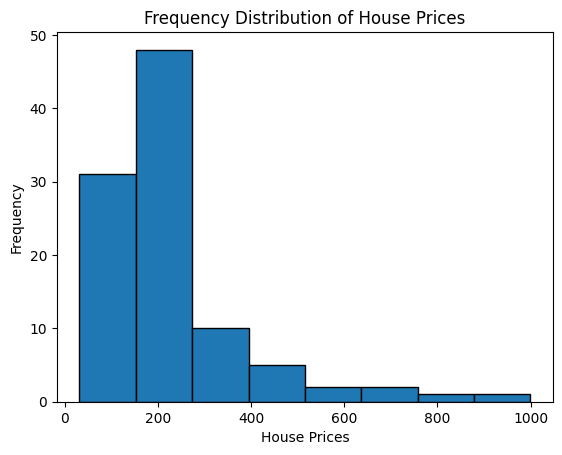

Max bin index: 1: [152.5, 273.5) with 48 homes = 48.0% of 100.
The distribution of house prices is unimodal and right-skewed.
Most houses (48.0%) are priced between $152.5K and $273.5K,
with a few outliers pulling the mean upward to $233.0K, which higher than the median of $198.90K.

Lower bound (mean - 1 std): $81.1K
Upper bound (mean + 1 std): $384.9K
Percentage of observations within bounds: 85.00%
This is a result of the fact that the distribution is right-skewed and far from 'Normal': mean 233.00 > median 198.90


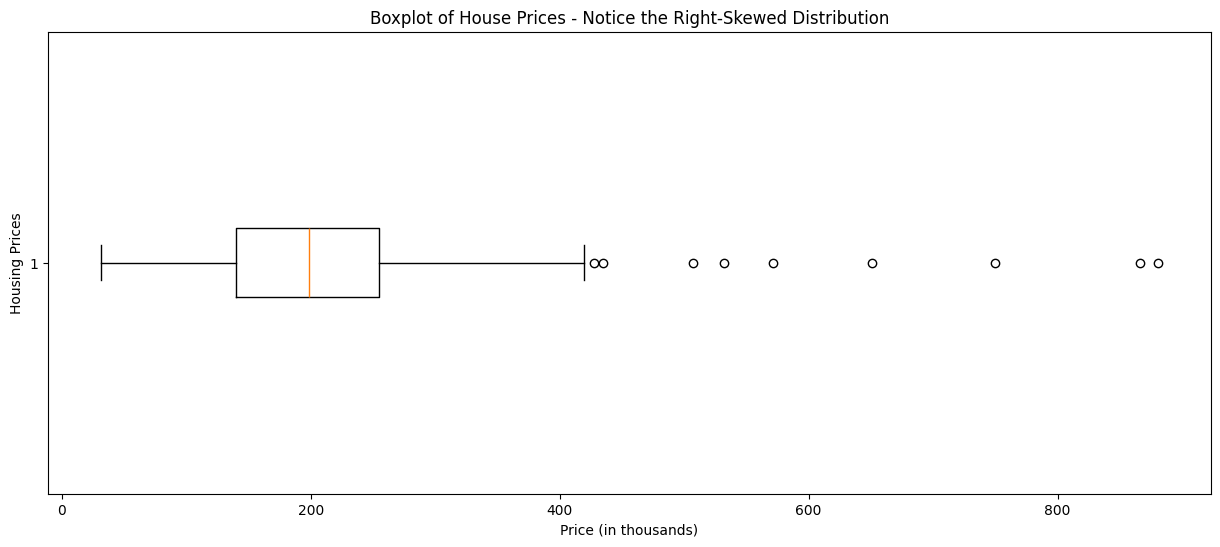

Lower fence = -32.1
Upper fence = 426.3
Outliers:
5     749.85
7     434.85
8     880.50
21    866.25
34    507.00
65    571.50
67    532.35
75    651.00
91    427.50
Name: price, dtype: float64
The whiskers are longer on the right, 9 outlier dots on the right side
and the median line is not to Q1 like I would expect a for aright-skewed distribution but,
all-in-all this indicates the righ-skewness of the distribution, confirming my hypothesis.

Descriptive Statistics Comparison:
Old houses (n=89):
  Mean: $207.85K
  Median: $190.80K
  Std Dev: $121.04K

New houses (n=11):
  Mean: $436.45K
  Median: $427.50K
  Std Dev: $219.83K

Differences:
  Mean difference: $228.59K
  Median difference: $236.70K


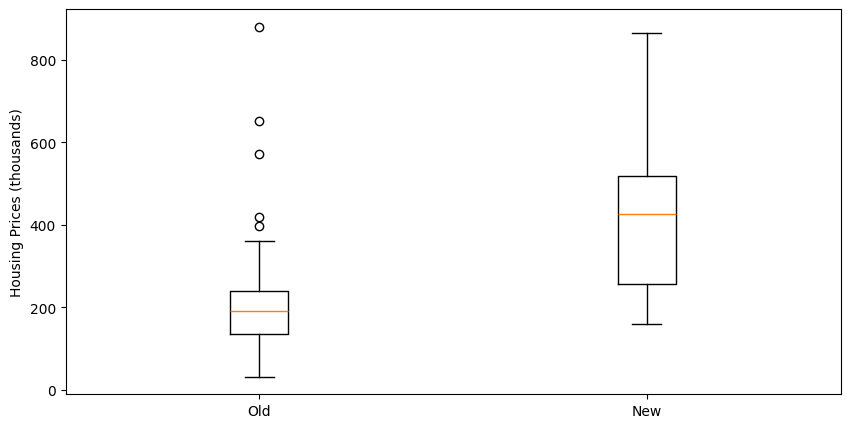


INFERENTIAL ANALYSIS

New house std dev: $219.83K
Old house std dev: $121.04K
Ratio of standard deviations: 1.82
We proceed under the equal-variance assumption (pooled method), as specified.

Within-Group Confidence Intervals (Descriptive)
New houses (n=11): mean = $436.45K
  95% CI for mew_new: ($288.76K, $584.13K)
Old houses (n=89): mean = $207.85K
  95% CI for mew_old: ($182.35K, $233.35K)
Comparison
Point estimate (x_new - x_old): $228.59K
Pooled standard error: $42.98K
Degrees of freedom: 98
t-critical (two-tailed): 1.9845
Margin of error: $85.30K
95% CI for (mew_new - mew_old): ($143.30K, $313.89K)

Interpretation
Since the entire CI is above 0, we have evidence at the 95% level
that new homes sell for more than older homes.

Two-sample t-test (equal variance assumed):
  t-statistic: 5.3183
  p-value: 0.0000
Reject null: Significant difference in means.

ASSUMPTIONS:

1) INDEPENDENCE
Each home sale is independent of the others and new and old home samples are
independent groups.

In [11]:
from textwrap import dedent
from math import floor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def ci_construct_two_stats(y1, y0, ci=0.95):
    """
    Constructs a Confidence interval to compare two population means
    using two independent samples, and assumes equal variance.
    ------------------------------------------------
    INPUT:
        y1: (list, np.array, pd.DataFrame, pd.Series)
            Sample of values for group 1 (e.g., new homes).
        y0: (list, np.array, pd.DataFrame, pd.Series)
            Sample of values for group 0 (e.g., older homes).
        ci: (float)
            Confidence Level (default 0.95)
    OUTPUT:
        tuple of values:
            (mew_hat_1, mew_hat_0, diff_hat, std_1, std_0, se_diff, df, t_crit, me, conf_interval)
    """
    if isinstance(y1, pd.DataFrame) and isinstance(y0, pd.DataFrame):
        y1, y0 = y1.iloc[:, 0], y0.iloc[:, 0]
    if isinstance(y1, pd.Series) and isinstance(y0, pd.Series):
        y1, y0 = y1.to_numpy(), y0.to_numpy()

    # Sample sizes
    n1, n0 = len(y1), len(y0)

    # Alpha for two-tailed CI
    alpha = (1 - ci) / 2

    # Sample stats
    mew_hat_1 = sum(y1) / n1
    mew_hat_0 = sum(y0) / n0
    diff_hat = mew_hat_1 - mew_hat_0
    std_1 = np.std(y1, ddof=1)
    std_0 = np.std(y0, ddof=1)

    # Standard error and degrees of freedom
    s_pooled = np.sqrt(((n1 - 1)*(std_1**2) + (n0 - 1)*(std_0**2)) / (n1 + n0 - 2))
    se_diff = s_pooled * np.sqrt((1/n1) + (1/n0))
    df = n1 + n0 - 2

    # t-critical value
    t_crit = stats.t.ppf(1 - alpha, df=df)

    # Margin of error + CI for (mu1 - mu0)
    me = t_crit * se_diff
    conf_interval = (diff_hat - me, diff_hat + me)

    return (mew_hat_1, mew_hat_0, diff_hat, std_1, std_0, se_diff, df, t_crit, me, conf_interval)


df = pd.read_csv("./house.dat", sep="\s+")

# Selling prices to be analyzed
prices = df["price"]
n = len(df)

# Stats
rng = max(prices) - min(prices)
mew = prices.mean()
med = prices.median()
stdev = prices.std()

# Sturges Rule for getting the bins
k = int(np.log2(n) + 1)
bin_width = int(rng / k)

# Stop value
stop = floor(max(prices) + bin_width)

# Create bins
bins = np.arange(min(prices),stop, bin_width)

print("n =", n)
print(f"Mean = {mew:.3f}")
print(f"Median = {med:.3f}")
print(f"Std dev = {stdev:.3f}\n")

# Plotting histogram
# Create the frequency distribution
# histogram(a, bins=10, range=None, density=None, weights=None)
counts, edges = np.histogram(prices, bins=bins)

# Display the frequency table with relative frequencies
print("Frequency Distribution (with Relative Frequencies):")
for i in range(len(counts)):
    rel_freq = counts[i] / n
    print(f"[{edges[i]:.1f} - {edges[i+1]:.1f}): {counts[i]} (Rel freq = {rel_freq:.3f})")

plt.hist(prices, bins=bins, edgecolor='black')
# Explanatory variable
plt.xlabel("House Prices")
plt.ylabel("Frequency")
plt.title("Frequency Distribution of House Prices")
plt.show()

# Get bin that contains the price range with the most houses
max_idx = np.argmax(counts)
lower = edges[max_idx]
upper = edges[max_idx + 1]
perc = counts[max_idx] / n * 100
print(f"Max bin index: {max_idx}: [{lower:.1f}, {upper:.1f}) "
      f"with {counts[max_idx]} homes = {perc:.1f}% of {n}.")

print(f"""The distribution of house prices is unimodal and right-skewed.
Most houses ({perc:.1f}%) are priced between ${lower:.1f}K and ${upper:.1f}K,
with a few outliers pulling the mean upward to ${mew:.1f}K, which higher than the median of ${med:.2f}K.""")


"""
Percentages of observations that fall within one std dev of the mean.
Why not close to 68% ?
"""
# mean +- 1*std dev
lower_bound = round(mew - stdev, 3)
upper_bound = round(mew + stdev, 3)

# Housing prices between lower/upper bound
inrange = sum((prices >= lower_bound) & (prices <= upper_bound))

# % within the bounds
perc_in = inrange / n * 100

print(f"\nLower bound (mean - 1 std): ${lower_bound:.1f}K")
print(f"Upper bound (mean + 1 std): ${upper_bound:.1f}K")
print(f"Percentage of observations within bounds: {perc_in:.2f}%")
print(f"This is a result of the fact that the distribution is right-skewed and far from 'Normal': mean {mew:.2f} > median {med:.2f}")

# Box PLot
plt.figure(figsize=(15, 6))
plt.boxplot(prices, vert=False)
plt.xlabel("Price (in thousands)")
plt.title("Boxplot of House Prices - Notice the Right-Skewed Distribution")
plt.ylabel("Housing Prices")
plt.show()

# Find outliers
Q1 = prices.quantile(0.25)
Q3 = prices.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = prices[(prices < lower_fence) | (prices > upper_fence)]
print(f"Lower fence = {lower_fence:.1f}")
print(f"Upper fence = {upper_fence:.1f}")
print("Outliers:")
print(outliers)

# Interpret
print("""The whiskers are longer on the right, 9 outlier dots on the right side
and the median line is not to Q1 like I would expect a for aright-skewed distribution but,
all-in-all this indicates the righ-skewness of the distribution, confirming my hypothesis.""")

# Comparing selling prices to new houses
mask = df["new"] == 1
new = df[mask]["price"]
old = df[~mask]["price"]

new_n = len(new)
old_n = len(old)

# Explanatory variable: new (categorical)
# Response variable: price (continuous)

# Descriptive Stats: Five Number SUmmary
new_mew = new.mean()
old_mew = old.mean()
new_med = new.median()
old_med = old.median()
new_std = new.std()
old_std = old.std()

# Ranges
new_rng = new.max() - new.min()
old_rng = old.max() - old.min()

# Changes
mew_dif = abs(new_mew - old_mew)
med_df = abs(new_med - old_med)
std_dif = abs(new_std - old_std)

# Output stats
print(f"\nDescriptive Statistics Comparison:")
print(f"Old houses (n={len(old)}):")
print(f"  Mean: ${old_mew:.2f}K")
print(f"  Median: ${old_med:.2f}K")
print(f"  Std Dev: ${old_std:.2f}K")

print(f"\nNew houses (n={len(new)}):")
print(f"  Mean: ${new_mew:.2f}K")
print(f"  Median: ${new_med:.2f}K")
print(f"  Std Dev: ${new_std:.2f}K")

print(f"\nDifferences:")
print(f"  Mean difference: ${mew_dif:.2f}K")
print(f"  Median difference: ${med_df:.2f}K")

# Plotting Old houses and pricing
plt.figure(figsize=(10, 5))
plt.boxplot([old, new], tick_labels=['Old', 'New'])
plt.ylabel("Housing Prices (thousands)")
plt.show()

"""
Extending code for:
The Houses data file at the book's website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.
"""

# INFERENTIAL ANALYSIS
print("\nINFERENTIAL ANALYSIS")
# Variance comparison (assumption check)
var_ratio = max(new_std, old_std) / min(new_std, old_std)
print(f"\nNew house std dev: ${new_std:.2f}K")
print(f"Old house std dev: ${old_std:.2f}K")
print(f"Ratio of standard deviations: {var_ratio:.2f}")
print("We proceed under the equal-variance assumption (pooled method), as specified.")

# W/in group CIs (descriptive)
print("\nWithin-Group Confidence Intervals (Descriptive)")
conf_level = 0.95

# New houses CI
new_se = new_std / np.sqrt(new_n)
t_value_new = stats.t.ppf((1 + conf_level) / 2, df=new_n-1)
margin_new = t_value_new * new_se
lower_new = new_mew - margin_new
upper_new = new_mew + margin_new
print(f"New houses (n={new_n}): mean = ${new_mew:.2f}K")
print(f"  95% CI for mew_new: (${lower_new:.2f}K, ${upper_new:.2f}K)")

# Old houses CI
old_se = old_std / np.sqrt(old_n)
t_value_old = stats.t.ppf((1 + conf_level) / 2, df=old_n-1)
margin_old = t_value_old * old_se
lower_old = old_mew - margin_old
upper_old = old_mew + margin_old
print(f"Old houses (n={old_n}): mean = ${old_mew:.2f}K")
print(f"  95% CI for mew_old: (${lower_old:.2f}K, ${upper_old:.2f}K)")

# INferential comparison
print("Comparison")
results = ci_construct_two_stats(new, old, ci=0.95)
mew_hat_1, mew_hat_0, diff_hat, std_1, std_0, se_diff, df_val, t_crit, me, conf_interval = results

print(f"Point estimate (x_new - x_old): ${diff_hat:.2f}K")
print(f"Pooled standard error: ${se_diff:.2f}K")
print(f"Degrees of freedom: {df_val}")
print(f"t-critical (two-tailed): {t_crit:.4f}")
print(f"Margin of error: ${me:.2f}K")
print(f"95% CI for (mew_new - mew_old): (${conf_interval[0]:.2f}K, ${conf_interval[1]:.2f}K)")

# Interpretation
print("\nInterpretation")
if conf_interval[0] > 0:
    print(f"Since the entire CI is above 0, we have evidence at the 95% level")
    print(f"that new homes sell for more than older homes.")
elif conf_interval[1] < 0:
    print(f"Since the entire CI is below 0, we have evidence at the 95% level")
    print(f"that new homes sell for less than older homes.")
else:
    print(f"Since the CI contains 0, we do not have sufficient evidence at the 95% level")
    print(f"to conclude a difference in mean selling prices.")

# Two-sample t-test (for p-value, consistent with CI)
t_stat, p_value = stats.ttest_ind(new, old)
print(f"\nTwo-sample t-test (equal variance assumed):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject null: Significant difference in means.")
else:
    print("No significant difference.")

# ASSUMPTIONS 
print("\nASSUMPTIONS:")
print(dedent(f"""
1) INDEPENDENCE
Each home sale is independent of the others and new and old home samples are
independent groups.

2) NORMALITY
Population distribution approximately normal, where CLT useful in the
comparisons as well.

3) EQUAL VARIANCES
             """))
print(f"\nThe sample mean difference of ${diff_hat:.2f}K is the point estimate for (mew_new - mew_old).")
print(f"""Assuming independence, approximate normality (supported by CLT given sample sizes),
and equal variances (as specified), the t-distribution represents uncertainty in our estimate.""")


## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


In [12]:
import numpy as np
from scipy import stats
from textwrap import dedent

# State A
n_a, x_a = 100, 59
p_hat_a = x_a / n_a

# State B
n_b, x_b = 1000, 525
p_hat_b = x_b / n_b

# null hypothesis value
pi_0 = 1/2

print(dedent(f"""
\nHYPOTHESIS TEST FOR PROPORTIONS:
Null: pi = {pi_0} (population evenly split)
pi > {pi_0} (Rep. majority - one-tailed)
             """))

# Test statistics: numerator = how far sample is fro null hypothesis
# Denominator = standard error under H_0 (expecte variability)
se_a, se_b = np.sqrt(pi_0 * (1 - pi_0) / n_a), np.sqrt(pi_0 * (1 - pi_0) / n_b)

# Z-scores
z_a = (p_hat_a - pi_0) / se_a
z_b = (p_hat_b - pi_0) / se_b

# p-values (one-tailed)
p_a = 1 - stats.norm.cdf(z_a)
p_b = 1 - stats.norm.cdf(z_b)

# OUtput results
print("\nState A")
print(f"Sample size (n):        {n_a}")
print(f"Sample proportion (p̂):  {p_hat_a:.3f}")
print(f"Standard error:         {se_a:.4f}")
print(f"z-statistic:            {z_a:.3f}")
print(f"p-value (one-tailed):   {p_a:.4f}")

print("\nState b")
print(f"Sample size (n):        {n_b}")
print(f"Sample proportion (p̂):  {p_hat_b:.3f}")
print(f"Standard error:         {se_b:.4f}")
print(f"z-statistic:            {z_b:.3f}")
print(f"p-value (one-tailed):   {p_b:.4f}")

# Comparison
print("\nComparison")
if p_a < p_b:
    stronger = "State a"
    weaker = "State b"
else:
    stronger = "State b"
    weaker = "State a"

print(f"\n{stronger} has STRONGER evidence for Republican victory")
print(f"(smaller p-value = more evidence against H₀)")

# Interpretation
print(dedent(f"""
State A shows stronger evidence because:
Even though state B has a larger sample size, state A's EFFECT SIZE, dividing y1_hat - y2_hat by the pooled standard deviation estimate (deviation from 1/2), which is much larger:

State A deviates by {(p_hat_a - pi_0)*100:.1f} percentage points.
State B deviates by {(p_hat_b - pi_0)*100:.1f} percentage points.

Z-stat balances both:
1) Effect size
2) Precision, how reliable the estimate its

Thus, State A's large effect size outdoes State B's precision advantage.
             """))




HYPOTHESIS TEST FOR PROPORTIONS:
Null: pi = 0.5 (population evenly split)
pi > 0.5 (Rep. majority - one-tailed)


State A
Sample size (n):        100
Sample proportion (p̂):  0.590
Standard error:         0.0500
z-statistic:            1.800
p-value (one-tailed):   0.0359

State b
Sample size (n):        1000
Sample proportion (p̂):  0.525
Standard error:         0.0158
z-statistic:            1.581
p-value (one-tailed):   0.0569

Comparison

State a has STRONGER evidence for Republican victory
(smaller p-value = more evidence against H₀)

State A shows stronger evidence because:
Even though state B has a larger sample size, state A's EFFECT SIZE, dividing y1_hat - y2_hat by the pooled standard deviation estimate (deviation from 1/2), which is much larger:

State A deviates by 9.0 percentage points.
State B deviates by 2.5 percentage points.

Z-stat balances both:
1) Effect size
2) Precision, how reliable the estimate its

Thus, State A's large effect size outdoes State B's precision

## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

`Your answer goes here`

In [13]:
import pandas as pd
from textwrap import dedent
import numpy as np
from scipy.stats import t

def ci_construction(y, cl=0.95):
    """
    Constructs a Confidence interval for the given sample with quantitative
    (discrete) values in order to infer the unknown population mean.
    ------------------------------------------------
    INPUT:
        y: (list, np.array, pd.DataFrame, pd.Series) Sample of values (not a large sample).
        cl: (float) Confidence Level (default 0.95)
    OUTPUT:
        tuple of values: (sample mean, sample standard deviation, standard error,
                          degrees of freedom, t-critical value, margin of error,
                          confidence interval)
    """
    if isinstance(y, pd.DataFrame):
        y = y.loc[:, 0]
    if isinstance(y, pd.Series):
        y = y.to_numpy()
    # Sample size
    n = len(y)
    # Confidence Level check
    if cl == 0.95:
        # t quantile having probability alpha in the right-tail
        alpha = 0.025
    else:
        alpha = (1 - cl) / 2
    # Sample Statistics
    mew_hat = sum(y) / n  # sample mean
    std = np.std(y, ddof=1)  # Sample standard deviation
    se = std / np.sqrt(n)  # Standard error
    # t-critical value
    df = n - 1  # Degrees of freedom
    t_crit = t.ppf(1 - alpha, df=df)
    # Margin of error
    me = t_crit * se
    # Confidence Interval for confidence level 95%
    ci = (mew_hat - me, mew_hat + me)
    return (mew_hat, std, se, df, t_crit, me, ci)

df = pd.read_csv("./students.dat", sep="\s+")

# a) 
# Isolate ideology variable
ideology = df["ideol"]

# Stats
x_bar, s, se, df, t_critical, margin_of_error, ci = ci_construction(ideology, cl=0.95)

# Output
print(f"Sample size n = {len(ideology)}")
print(f"Sample mean x̄ = {x_bar:.3f}")
print(f"Sample standard deviation s = {s:.3f}")
print(f"Standard error SE = s/√n = {se:.3f}\n")


Sample size n = 60
Sample mean x̄ = 3.033
Sample standard deviation s = 1.636
Standard error SE = s/√n = 0.211



(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


`Your answer goes here`

In [14]:
# b) CONFIDENCE INTERVAL (95%)
print("\nCONFIDENCE INTERVAL FOR POPULATION MEAN (POLITICAL IDEOLOGY)\n")

print(f"Degrees of freedom = {df}")
print(f"Critical t value (95%) = {t_critical:.3f}")
print(f"Margin of error = {margin_of_error:.3f}\n")

print(f"95% confidence interval for μ: ({ci[0]:.3f}, {ci[1]:.3f})\n")

# Interpretation]
print(dedent(f"""
We can be 95% confident the true population mean for political ideology lies between {ci[0]:.2f} and {ci[1]:.2f} on the 1-y scale.
             """))

mu_null = 4

if ci[0] <= mu_null <= ci[1]:
    print(dedent(f""" 
\nSince the null hypothesis of the population mean is {mu_null}, it's inside
                 the confidence interval and we fail to reject the nully
                 hypothesis at the significance level of 0.05.
The data doesn't provide enough evidence that the population mean ideology
                 differs from 'moderate.'
                 """))

else:
    print(dedent(f"""
Since the null hypothesis of the population mean is {mu_null}, it's not inside in the confidence interval so we reject the null
hypothesis at the significance level 0.05. 
The results indicate the population mean ideology differs from 'moderate' and is lower, on average, meaning more liberal.
                 """))



CONFIDENCE INTERVAL FOR POPULATION MEAN (POLITICAL IDEOLOGY)

Degrees of freedom = 59
Critical t value (95%) = 2.001
Margin of error = 0.423

95% confidence interval for μ: (2.611, 3.456)


We can be 95% confident the true population mean for political ideology lies between 2.61 and 3.46 on the 1-y scale.


Since the null hypothesis of the population mean is 4, it's not inside in the confidence interval so we reject the null
hypothesis at the significance level 0.05. 
The results indicate the population mean ideology differs from 'moderate' and is lower, on average, meaning more liberal.



## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

`Your answer goes here`


Survived group (n = 1041):
  Sample mean: 20.646 kg
  Sample SD: 4.900 kg

Died group (n = 318):
  Sample mean: 15.998 kg
  Sample SD: 5.327 kg

Point estimate (ȳ_surv - ȳ_died): 4.648 kg
Pooled standard deviation: 5.003 kg
Standard error of difference: 0.321 kg
Degrees of freedom: df = 1041 + 318 - 2 = 1357
t-statistic: t = 4.648 / 0.321 = 14.500
P-value (two-tailed): 0.0000

[scipy verification: t = 14.500, p = 0.0000]


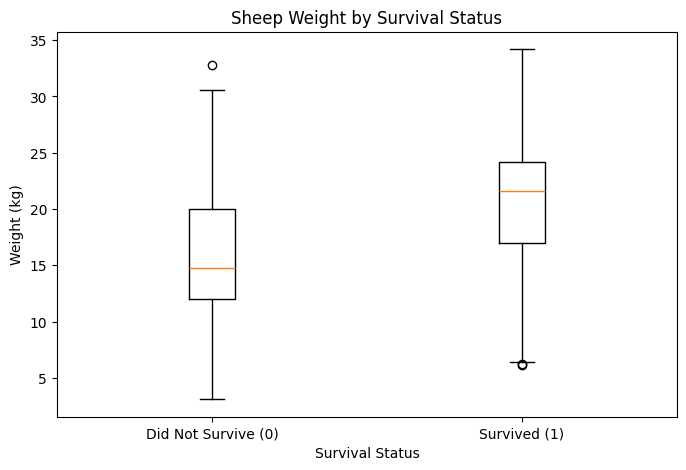


The p-value 0.0000 is the probability of observing a difference in sample means of
4.648 kg or more extreme, given that the null hypothesis is true.

Since p = 0.0000 < alpha = 0.025,
we reject the null hypothesis.

There is statistically significant evidence that mean weight differs between sheep that survived and those that did not.

Sheep that survived had a higher mean weight (20.65 kg) compared to those that died (16.00 kg), a difference of 4.65 kg.



ASSUMPTIONS
1) Independence
2) Normality
3) Random sampling
4) Equal variances



In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
from textwrap import dedent

df = pd.read_csv("sheep.dat", sep="\s+")

# Splitting survival status
live = df[df["survival"] == 1]["weight"]
died = df[df["survival"] == 0]["weight"]

# Sample sizes
n_surv = len(live)
n_died = len(died)

# Sample Statistics
mean_surv = np.mean(live)
mean_died = np.mean(died)
std_surv = np.std(live, ddof=1)
std_died = np.std(died, ddof=1)

# Point estimate of difference
diff_hat = mean_surv - mean_died

# Pooled standard deviation (assumes equal variance)
s_pooled = np.sqrt(((n_surv - 1) * std_surv**2 + (n_died - 1) * std_died**2) /
                   (n_surv + n_died - 2))

# Standard error of the difference
se_diff = s_pooled * np.sqrt(1/n_surv + 1/n_died)

# Degrees of freedom
dof = n_surv + n_died - 2

# t-statistic
t_stat = diff_hat / se_diff

# P-value (two-tailed)
p_value = 2 * (1 - t.cdf(abs(t_stat), df=dof))

# Verify with scipy
t_check, p_check = stats.ttest_ind(live, died, equal_var=True)

print(f"\nSurvived group (n = {n_surv}):")
print(f"  Sample mean: {mean_surv:.3f} kg")
print(f"  Sample SD: {std_surv:.3f} kg")

print(f"\nDied group (n = {n_died}):")
print(f"  Sample mean: {mean_died:.3f} kg")
print(f"  Sample SD: {std_died:.3f} kg")

print(f"\nPoint estimate (ȳ_surv - ȳ_died): {diff_hat:.3f} kg")
print(f"Pooled standard deviation: {s_pooled:.3f} kg")
print(f"Standard error of difference: {se_diff:.3f} kg")
print(f"Degrees of freedom: df = {n_surv} + {n_died} - 2 = {dof}")
print(f"t-statistic: t = {diff_hat:.3f} / {se_diff:.3f} = {t_stat:.3f}")
print(f"P-value (two-tailed): {p_value:.4f}")

print(f"\n[scipy verification: t = {t_check:.3f}, p = {p_check:.4f}]")

# Boxplot comparison
plt.figure(figsize=(8, 5))
plt.boxplot([died, live], tick_labels=['Did Not Survive (0)', 'Survived (1)'])
plt.ylabel("Weight (kg)")
plt.xlabel("Survival Status")
plt.title("Sheep Weight by Survival Status")
plt.show()

# Interpretation
print(dedent(f"""
The p-value {p_value:.4f} is the probability of observing a difference in sample means of
{abs(diff_hat):.3f} kg or more extreme, given that the null hypothesis is true.

Since p = {p_value:.4f} {"<" if p_value < alpha else "≥"} alpha = {alpha},
we {"reject" if p_value < alpha else "fail to reject"} the null hypothesis.

{"There is statistically significant evidence that mean weight differs between sheep that survived and those that did not."
 if p_value < alpha else
 "There is insufficient evidence that mean weight differs by survival status."}

{"Sheep that survived had a higher mean weight "
 f"({mean_surv:.2f} kg) compared to those that died "
 f"({mean_died:.2f} kg), a difference of {diff_hat:.2f} kg."
 if diff_hat > 0 else ""}
"""))

print(dedent(f"""
\nASSUMPTIONS
1) Independence
2) Normality
3) Random sampling
4) Equal variances
             """))


## Problem 5.23. Sentiment Toward AI and Gender

You will use a mock survey dataset that measures public sentiment toward artificial intelligence. Your task is to generate the dataset, construct a contingency table, and test whether sentiment depends on gender

### Dataset creation

Run the starter code below to generate the dataset as a pandas DataFrame named `df_ai`.

In [17]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()

,sentiment,gender,age,ai_usage_frequency,trust_in_ai
0,Neutral,Male,55,Weekly,2
1,Neutral,Male,23,Rarely,3
2,Positive,Male,27,Daily,5
3,Positive,Female,29,Daily,1
4,Positive,Female,58,Rarely,5


| Variable           | Description                         |
|--------------------|-------------------------------------|
| `sentiment`          | Sentiment toward AI                 |
| `gender`             | Gender identity                     |
| `age`                | Respondent age                      |
| `ai_usage_frequency` | AI tool usage frequency             |
| `trust_in_ai`        | Trust in AI from 1 to 5             |

Using the dataset you just created:

(a) Form a contingency table that cross classifies sentiment by gender.

(b) For the hypothesis $H_0:$ sentiment toward AI is independent of gender, conduct a chi squared test of independence.

(c) Interpret the results in the context of attitudes toward AI.

(a) `Your answer goes here`

In [18]:
import numpy as np
import pandas as pd
from textwrap import dedent
from scipy.stats import chi2_contingency

import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()

# a) Contingency table
ct = pd.crosstab(df_ai["sentiment"], df_ai["gender"])

print("Contingency Table: Sentiment by Gender")
print(ct, "\n")


Contingency Table: Sentiment by Gender
gender     Female  Male  Other
sentiment                     
Negative       30    38      3
Neutral        48    49      0
Positive       63    63      6 



(b) `Your answer goes here`


In [19]:
# b) Chi-squared test of independence
chi2, p_val, dof, expected = chi2_contingency(ct, correction=False)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

print(dedent(f"""\n
Chi-sqaured test of independence
chi-stat: {chi2:.4f}
Degrees of Freedom: {dof}
p-value: {p_val:.3f}
             """))

print("Expected counts under H0 (independence):")
print(expected_df.round(2), "\n")

# Check for validity via finding the smallest cell count of the contingency table
# Converts it to a numpy array (better than using .values for the DataFrame)
min_expected = expected_df.to_numpy().min()
print(f"Min expected cell count = {min_expected}")

if min_expected < 5:
    print("Chi-square approx could be weak!")

else:
    print("Expected counts condition looks good since all cell counts are approx >= 5")

# Effect Size
r, c = ct.shape
k = min(r - 1, c - 1)
cramers_v = np.sqrt(chi2 / (n * k))
# From section 4.5.2 of the text
print("\nEffect Size")
print(f"Cramér's V = {cramers_v:.4f}\n")




Chi-sqaured test of independence
chi-stat: 5.1164
Degrees of Freedom: 4
p-value: 0.276

Expected counts under H0 (independence):
gender     Female  Male  Other
sentiment                     
Negative    33.37  35.5   2.13
Neutral     45.59  48.5   2.91
Positive    62.04  66.0   3.96 

Min expected cell count = 2.13
Chi-square approx could be weak!

Effect Size
Cramér's V = 0.0923



(c) `Your answer goes here`


In [20]:
# c) INterpretation
# Significance level
alpha = 0.05

if p_val <= alpha:
    decision = "reject null"
    print(f"Significance level alpha = {alpha}")
    print(f"Decision: {decision}")
    print(dedent("""
There is statistically significant evidence the sentiment towards AI is associated with gender.
                 """))

else:
    decision = "fail to reject null"
    print(f"Significance level alpha = {alpha}")
    print(f"Decision: {decision}")
    print(dedent("""
There isn't enough evidence that the sentiment towards AI has to do with gender.
                 """))


print(
    f"- The chi-square test answers: 'Is there evidence of *any* association?' (p-value)\n"
    f"- Cramér's V answers: 'How strong is the association?' (effect size)\n"
    f"- Standardized residuals show which (sentiment, gender) cells deviate most from independence.\n"
    f"  As a rule of thumb, |residual| ≳ 2 is often considered a noticeable deviation.\n"
)


Significance level alpha = 0.05
Decision: fail to reject null

There isn't enough evidence that the sentiment towards AI has to do with gender.

- The chi-square test answers: 'Is there evidence of *any* association?' (p-value)
- Cramér's V answers: 'How strong is the association?' (effect size)
- Standardized residuals show which (sentiment, gender) cells deviate most from independence.
  As a rule of thumb, |residual| ≳ 2 is often considered a noticeable deviation.

